# Notebook 02: Monte Carlo Tree Search

Este notebook é dedicado exclusivamente ao `MCTS` como método de planeamento para o Connect Four.

## Objetivo

O objetivo deste notebook é:

- testar a configuração principal do `MCTS`;
- estudar o impacto do número de simulações;
- observar partidas concretas;
- decidir que orçamento de simulações faz mais sentido para o relatório e para a comparação final.

## Passo 1: Preparação do ambiente

Importamos o código necessário para trabalhar com o `MCTS`, os baselines, as utilidades de torneio e a renderização textual do tabuleiro.

In [1]:
from __future__ import annotations

import json
import statistics
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUTPUTS = ROOT / "outputs"
NOTEBOOK_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TORCH_DEVICE = torch.device(NOTEBOOK_DEVICE)
if NOTEBOOK_DEVICE == "cuda":
    torch.set_default_device(TORCH_DEVICE)
print(
    {
        "torch_version": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_device_count": torch.cuda.device_count(),
        "device": NOTEBOOK_DEVICE,
        "cuda_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    }
)
OUTPUTS

from connect4_rl.agents.baselines import HeuristicAgent, RandomAgent
from connect4_rl.agents.planning import MCTSAgent
from connect4_rl.envs.connect_four import apply_action, initial_state, is_terminal, legal_actions, render_ascii
from connect4_rl.experiments import round_robin


{'torch_version': '2.11.0+cu130', 'cuda_available': True, 'cuda_device_count': 1, 'device': 'cuda', 'cuda_name': 'NVIDIA GeForce RTX 5060 Laptop GPU'}


## Passo 2: Configuração da experiência de MCTS

Nesta célula controlamos a experiência principal do `MCTS`.

- `run_mcts_tournament = True`: executa o torneio da configuração principal.
- `run_mcts_sweep = False`: ativa ou desativa a análise de vários orçamentos de simulação.
- `games_per_pair`: número de jogos por confronto.
- `mcts_simulations`: número de simulações usadas pela configuração principal.
- `simulation_values`: lista de orçamentos testados no varrimento.

In [2]:
run_mcts_tournament = True
run_mcts_sweep = True

seed = 7
games_per_pair = 4
mcts_simulations = 80
simulation_values = [20, 40, 80, 120]


## Passo 3: Teste da configuração principal de MCTS

Aqui colocamos o `MCTS` a jogar contra os baselines para perceber se a configuração escolhida já é forte o suficiente.

In [3]:
mcts_results = {}

if run_mcts_tournament:
    mcts_factories = {
        "random": lambda: RandomAgent(seed=seed),
        "heuristic": lambda: HeuristicAgent(seed=seed),
        "mcts": lambda: MCTSAgent(simulations=mcts_simulations, rollout_seed=seed),
    }
    mcts_results = round_robin(mcts_factories, games_per_pair=games_per_pair)
    mcts_results
else:
    print("Set run_mcts_tournament = True to test the chosen MCTS configuration.")


## Passo 4: Varrimento do orçamento de simulações

Esta célula compara vários números de simulações para perceber como o desempenho do `MCTS` muda com o custo computacional.

In [4]:
sweep_results = {}

if run_mcts_sweep:
    for sims in simulation_values:
        sweep_factories = {
            "random": lambda: RandomAgent(seed=seed),
            "heuristic": lambda: HeuristicAgent(seed=seed),
            "mcts": lambda s=sims: MCTSAgent(simulations=s, rollout_seed=seed),
        }
        sweep_results[sims] = round_robin(sweep_factories, games_per_pair=20)["mcts"]
    sweep_results
else:
    print("Set run_mcts_sweep = True to compare simulation budgets.")


## Passo 5: Análise dos resultados do MCTS

Transformamos os resultados do varrimento em gráficos para perceber a relação entre orçamento de procura, vitórias e derrotas.

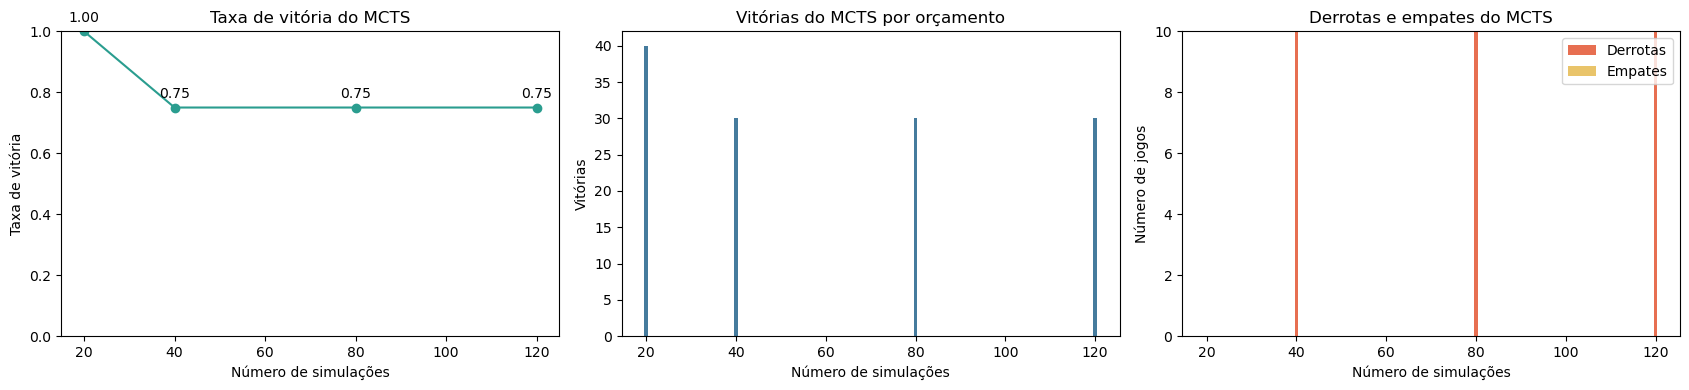

{20: {'win_rate': 1.0, 'wins': 40, 'losses': 0, 'draws': 0, 'games': 40},
 40: {'win_rate': 0.75, 'wins': 30, 'losses': 10, 'draws': 0, 'games': 40},
 80: {'win_rate': 0.75, 'wins': 30, 'losses': 10, 'draws': 0, 'games': 40},
 120: {'win_rate': 0.75, 'wins': 30, 'losses': 10, 'draws': 0, 'games': 40}}

In [5]:
if sweep_results:
    x = list(sweep_results.keys())
    win_rates = [float(sweep_results[s].get("win_rate", 0.0)) for s in x]
    wins = [int(sweep_results[s].get("wins", 0)) for s in x]
    draws = [int(sweep_results[s].get("draws", 0)) for s in x]
    losses = []
    for s in x:
        result = sweep_results[s]
        if "losses" in result:
            losses.append(int(result["losses"]))
        else:
            games = int(result.get("games", 0))
            draws_value = int(result.get("draws", 0))
            losses.append(max(0, games - int(result.get("wins", 0)) - draws_value))

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    axes[0].plot(x, win_rates, marker="o", color="#2a9d8f")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title("Taxa de vitória do MCTS")
    axes[0].set_xlabel("Número de simulações")
    axes[0].set_ylabel("Taxa de vitória")
    for sims, value in zip(x, win_rates):
        axes[0].text(sims, value + 0.03, f"{value:.2f}", ha="center")

    axes[1].bar(x, wins, color="#457b9d")
    axes[1].set_title("Vitórias do MCTS por orçamento")
    axes[1].set_xlabel("Número de simulações")
    axes[1].set_ylabel("Vitórias")

    axes[2].bar(x, losses, color="#e76f51", label="Derrotas")
    axes[2].bar(x, draws, bottom=losses, color="#e9c46a", label="Empates")
    axes[2].set_title("Derrotas e empates do MCTS")
    axes[2].set_xlabel("Número de simulações")
    axes[2].set_ylabel("Número de jogos")
    axes[2].legend()

    fig.tight_layout()
    plt.show()

summary = {}
for sims, result in sweep_results.items():
    wins_value = int(result.get("wins", 0))
    draws_value = int(result.get("draws", 0))
    games_value = int(result.get("games", 0))
    losses_value = int(result.get("losses", max(0, games_value - wins_value - draws_value)))
    summary[sims] = {
        "win_rate": float(result.get("win_rate", 0.0)),
        "wins": wins_value,
        "losses": losses_value,
        "draws": draws_value,
        "games": games_value,
    }
summary


## Passo 6: Visualização de uma partida do MCTS

Definimos a função de renderização da partida e mostramos um jogo concreto do `MCTS` contra o agente heurístico.

In [6]:
def play_and_render(agent, opponent, controlled_player: int = 1) -> str:
    state = initial_state()
    transcript = ["Initial board", render_ascii(state), ""]
    move_idx = 0
    while not is_terminal(state):
        move_idx += 1
        if state.current_player == controlled_player:
            action = agent.select_action(state, legal_actions(state))
            actor = agent.name
        else:
            action = opponent.select_action(state, legal_actions(state))
            actor = opponent.name
        state = apply_action(state, action)
        transcript.append(f"Move {move_idx}: {actor} played column {action}")
        transcript.append(render_ascii(state))
        transcript.append("")

    transcript.append(f"Winner: {state.winner}")
    return "\n".join(transcript)

strong_mcts = MCTSAgent(simulations=max(simulation_values), rollout_seed=seed)
print(play_and_render(strong_mcts, HeuristicAgent(seed=seed), controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: mcts played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: heuristic played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 3: mcts played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 4: heuristic played column 3
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. . . X . . .
0 1 2 3 4 5 6

Move 5: mcts played column 1
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. . . O . . .
. X . X . . .
0 1 2 3 4 5 6

Move 6: heuristic played column 1
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. O . O . . .
. X . X . . .
0 1 2 3 4 5 6

Move 7: mcts played column 2
. . . . . . .
. . . . . . .
. . . O . . .
. . . X . . .
. O . O . . .
. X X

## Passo 7: Confronto MCTS contra MCTS

Aqui observamos um jogo entre duas instâncias do mesmo método, para perceber o tipo de decisões que o `MCTS` tende a tomar sem influência de um adversário mais fraco.

In [7]:
mirror_mcts = MCTSAgent(simulations=mcts_simulations, rollout_seed=seed + 1)
print(play_and_render(MCTSAgent(simulations=mcts_simulations, rollout_seed=seed), mirror_mcts, controlled_player=1))


Initial board
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
0 1 2 3 4 5 6

Move 1: mcts played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
0 1 2 3 4 5 6

Move 2: mcts played column 1
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. O . X . . .
0 1 2 3 4 5 6

Move 3: mcts played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. O . X . . .
0 1 2 3 4 5 6

Move 4: mcts played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. O . X O . .
0 1 2 3 4 5 6

Move 5: mcts played column 3
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X . . .
. O . X O . .
0 1 2 3 4 5 6

Move 6: mcts played column 4
. . . . . . .
. . . . . . .
. . . . . . .
. . . X . . .
. . . X O . .
. O . X O . .
0 1 2 3 4 5 6

Move 7: mcts played column 3
. . . . . . .
. . . . . . .
. . . X . . .
. . . X . . .
. . . X O . .
. O . X O . .
0 1 2 

## Fecho

Este notebook deve permitir justificar, com resultados e exemplos qualitativos, o papel do `MCTS` como método forte de referência no projeto.